R^2 Score: 0.9783
Error Absoluto Medio (MAE): 1.16 ºC


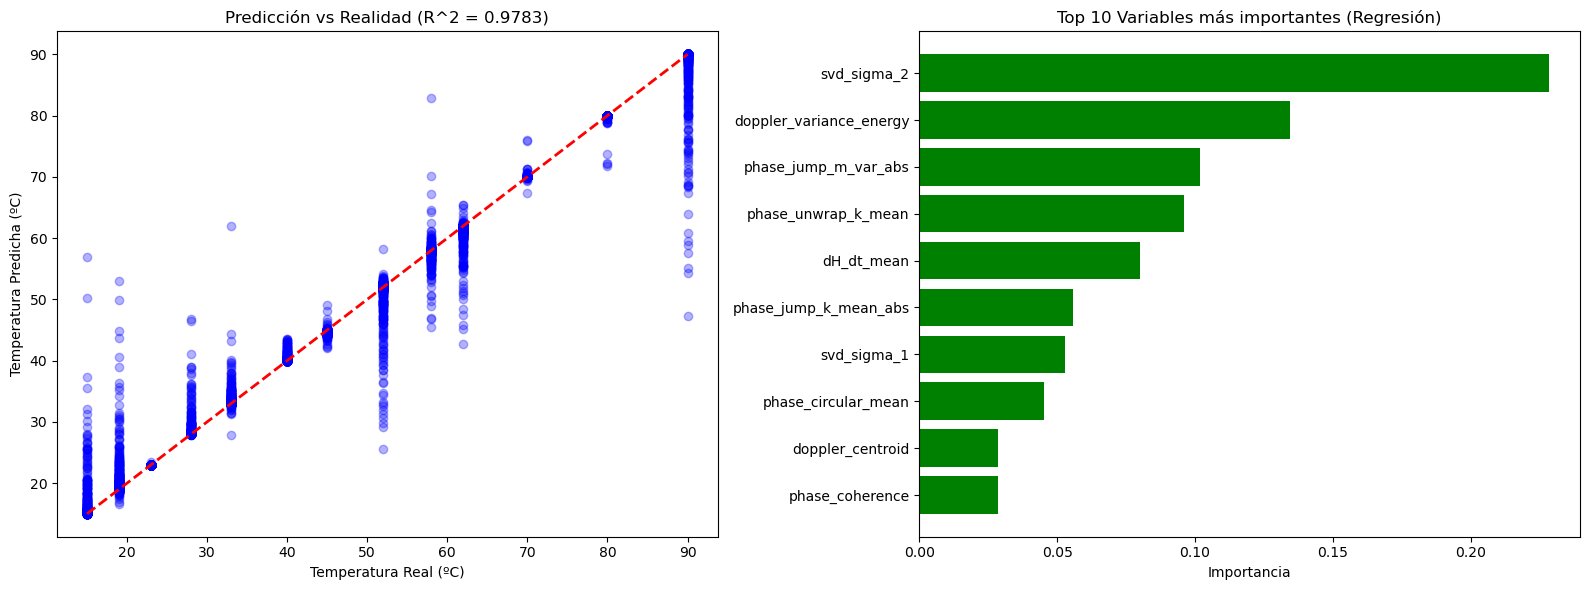

In [8]:
# TODAS LAS VARIABLES QUE DEPENDEN DEL DOPPLER

#phase_circular_mean
#phase_circular_variance
#phase_coherence
#phase_unwrap_m_mean
#phase_unwrap_m_var
#phase_unwrap_m_slope_mean
#phase_unwrap_m_slope_var
#phase_unwrap_m_slope_rms
#phase_unwrap_k_mean
#phase_unwrap_k_var
#phase_unwrap_k_slope_mean
#phase_unwrap_k_slope_var
#phase_unwrap_k_slope_rms
#phase_jump_m_mean_abs
#phase_jump_m_var_abs
#phase_jump_m_max_abs
#phase_jump_m_rms_abs
#phase_jump_m_count
#phase_jump_m_ratio
#phase_jump_k_mean_abs
#phase_jump_k_var_abs
#phase_jump_k_max_abs
#phase_jump_k_rms_abs
#phase_jump_k_count
#phase_jump_k_ratio
#svd_sigma_1
#svd_sigma_2
#svd_sigma_ratio
#svd_energy_ratio_mode1
#svd_spectral_flatness
#dH_dt_mean
#dH_dt_max
#doppler_variance_energy
#doppler_centroid
#doppler_spread

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Cargar datos
df = pd.read_csv(r'C:\Users\Joan Daniel\Documents\UPV quinto\Commov\Codigo-ISAC\Joanda\dataset_features_temperatura.csv')

# 2. Variables
dynamic_features = df.filter(regex='phase|doppler|dH_dt|svd').columns.tolist()
X = df[dynamic_features]
y = df['temperature'] # Ahora se usa como número, sin pasarlo a string

# 3. Dividir
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Entrenar el Regresor
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)

# 5. Predecir y calcular R^2
y_pred = rf_reg.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R^2 Score: {r2:.4f}")
print(f"Error Absoluto Medio (MAE): {mae:.2f} ºC")

# 6. Gráficas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica de Dispersión (Realidad vs Predicción)
ax1.scatter(y_test, y_pred, alpha=0.3, color='blue')
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax1.set_xlabel('Temperatura Real (ºC)')
ax1.set_ylabel('Temperatura Predicha (ºC)')
ax1.set_title(f'Predicción vs Realidad (R^2 = {r2:.4f})')

# Importancia Top 10
importances = rf_reg.feature_importances_
indices = np.argsort(importances)[::-1][:10]
ax2.barh(range(10), importances[indices][::-1], align='center', color='green')
ax2.set_yticks(range(10))
ax2.set_yticklabels([dynamic_features[i] for i in indices][::-1])
ax2.set_title('Top 10 Variables más importantes (Regresión)')
ax2.set_xlabel('Importancia')

plt.tight_layout()
plt.show()

1. Analizando cuáles son las 10 mejores variables...

--- LAS 10 VARIABLES SELECCIONADAS SON ---
1. svd_sigma_2
2. phase_jump_m_var_abs
3. doppler_variance_energy
4. phase_unwrap_k_mean
5. svd_sigma_1
6. dH_dt_mean
7. phase_jump_k_mean_abs
8. phase_circular_mean
9. phase_coherence
10. doppler_centroid
------------------------------------------

2. Entrenando el modelo definitivo SOLO con esas 10 variables...
RESULTADOS FINALES:
R^2 Score: 0.9801
Error Absoluto Medio (MAE): 1.00 ºC


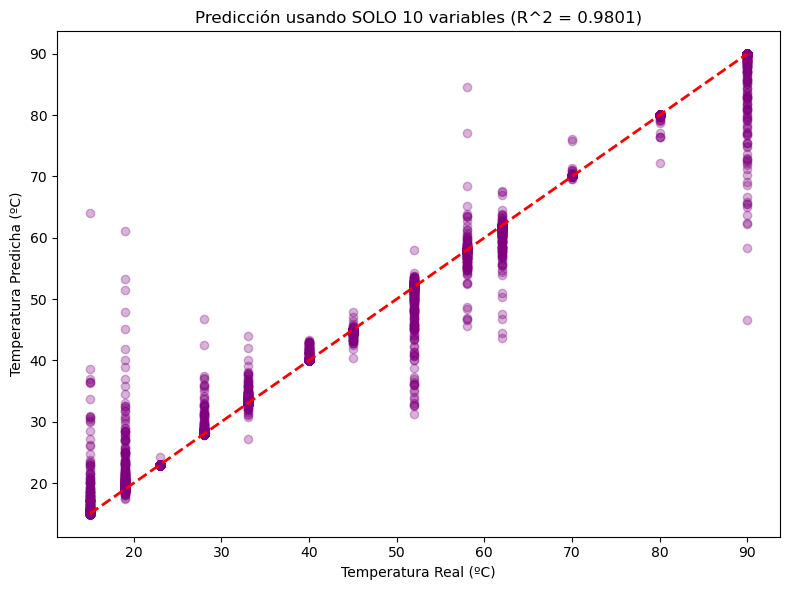

In [10]:
# AHORA SOLO LAS 10 VARIABLES MÁS IMPORTANTES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Cargar los datos
df = pd.read_csv(r'C:\Users\Joan Daniel\Documents\UPV quinto\Commov\Codigo-ISAC\Joanda\dataset_features_temperatura.csv')

# 2. Coger las 35 variables dinámicas iniciales y la temperatura
dynamic_features = df.filter(regex='phase|doppler|dH_dt|svd').columns.tolist()
X_full = df[dynamic_features]
y = df['temperature']

# ==========================================
# EL FILTRO: Buscar las 10 mejores
# ==========================================
print("1. Analizando cuáles son las 10 mejores variables...")
# Entrenamos un modelo rápido solo para ver qué variables le gustan más
rf_explorador = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_explorador.fit(X_full, y)

# Extraer el Top 10
importances = rf_explorador.feature_importances_
indices_top10 = np.argsort(importances)[::-1][:10]
top_10_features = [dynamic_features[i] for i in indices_top10]

print("\n--- LAS 10 VARIABLES SELECCIONADAS SON ---")
for i, var in enumerate(top_10_features, 1):
    print(f"{i}. {var}")
print("------------------------------------------\n")

# ==========================================
# ENTRENAR EL MODELO FINAL (Solo con las 10)
# ==========================================
print("2. Entrenando el modelo definitivo SOLO con esas 10 variables...")
# CREAMOS EL NUEVO SET DE DATOS FILTRADO
X_filtrado = df[top_10_features]

# Dividimos en Train/Test pero usando X_filtrado
X_train, X_test, y_train, y_test = train_test_split(X_filtrado, y, test_size=0.2, random_state=42)

# Entrenamos el Random Forest Definitivo
rf_final = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)

# Predecir y evaluar
y_pred = rf_final.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"RESULTADOS FINALES:")
print(f"R^2 Score: {r2:.4f}")
print(f"Error Absoluto Medio (MAE): {mae:.2f} ºC")

# ==========================================
# GRÁFICA DE COMPARACIÓN (Real vs Predicción)
# ==========================================
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='purple')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Línea ideal
plt.xlabel('Temperatura Real (ºC)')
plt.ylabel('Temperatura Predicha (ºC)')
plt.title(f'Predicción usando SOLO 10 variables (R^2 = {r2:.4f})')
plt.tight_layout()
plt.show()

FASE 1: Eliminando variables gemelas (Correlación > 0.90)...
--------------------------------------------------
LISTA DE VARIABLES NO CORRELADAS (17 en total):
--------------------------------------------------
1. phase_circular_mean
2. phase_circular_variance
3. phase_unwrap_m_mean
4. phase_unwrap_m_var
5. phase_unwrap_m_slope_mean
6. phase_unwrap_m_slope_var
7. phase_unwrap_k_mean
8. phase_unwrap_k_var
9. phase_jump_m_max_abs
10. phase_jump_m_count
11. phase_jump_m_ratio
12. phase_jump_k_max_abs
13. phase_jump_k_count
14. phase_jump_k_ratio
15. svd_sigma_1
16. dH_dt_max
17. doppler_centroid
--------------------------------------------------

FASE 2: Analizando la importancia para extraer el Top 17...
EL TOP 17 DEFINITIVO ES:
['phase_unwrap_m_slope_var', 'phase_unwrap_k_mean', 'svd_sigma_1', 'phase_circular_variance', 'phase_circular_mean', 'doppler_centroid', 'dH_dt_max', 'phase_unwrap_k_var', 'phase_unwrap_m_mean', 'phase_unwrap_m_var', 'phase_unwrap_m_slope_mean', 'phase_jump_k_max

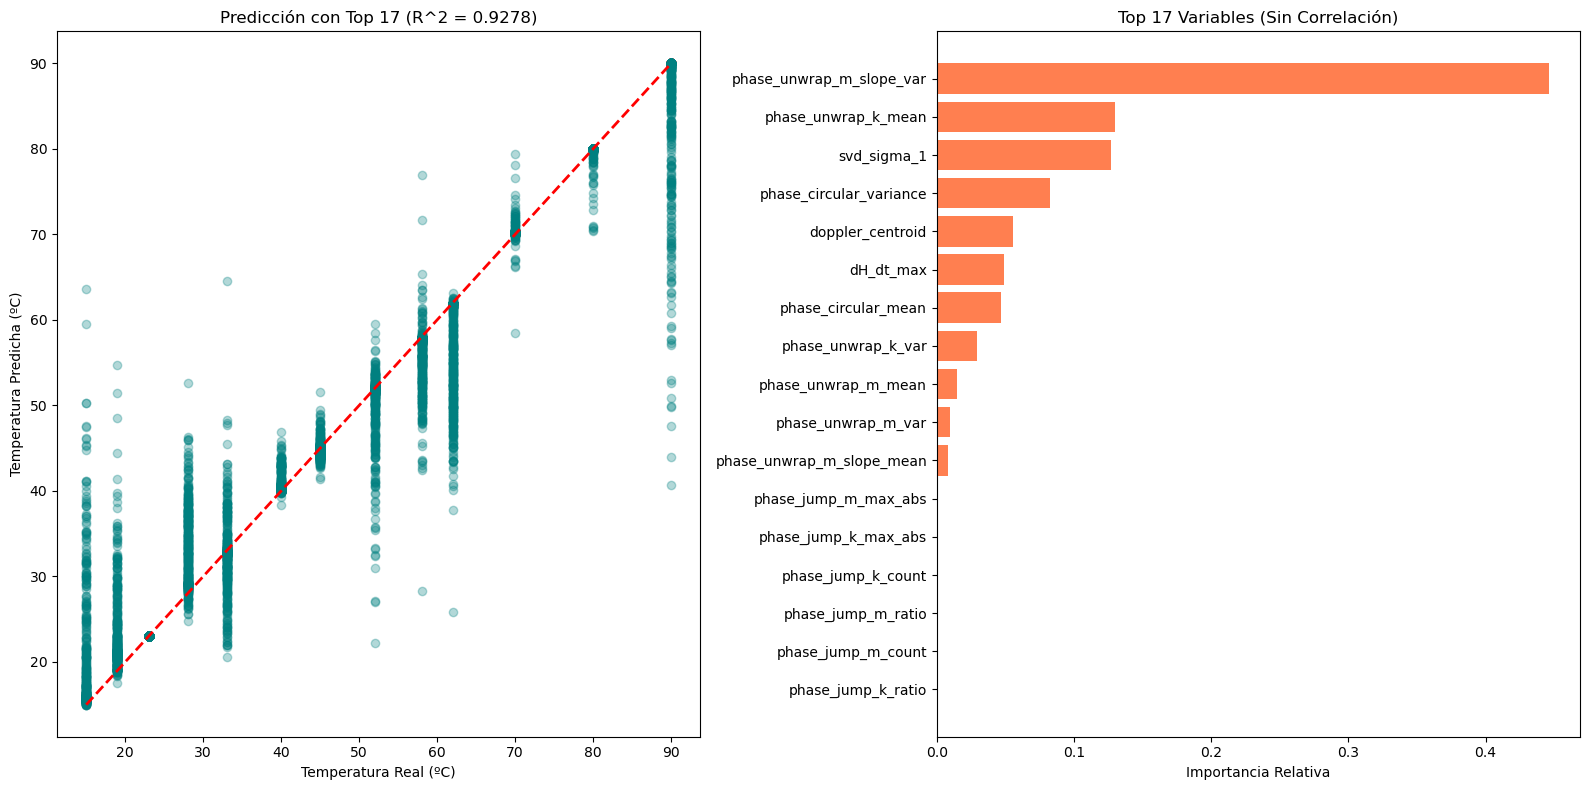

In [14]:
# Extracción de las variables no correladas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# ==========================================
# 1. CARGAR DATOS
# ==========================================
df = pd.read_csv(r'C:\Users\Joan Daniel\Documents\UPV quinto\Commov\Codigo-ISAC\Joanda\dataset_features_temperatura.csv')

# Coger TODAS las variables dinámicas iniciales
dynamic_features = df.filter(regex='phase|doppler|dH_dt|svd').columns.tolist()
X_all = df[dynamic_features]
y = df['temperature']

# ==========================================
# FASE 1: FILTRO DE CORRELACIÓN (>0.90)
# ==========================================
print("FASE 1: Eliminando variables gemelas (Correlación > 0.90)...")
matriz_corr = X_all.corr().abs()
upper = matriz_corr.where(np.triu(np.ones(matriz_corr.shape), k=1).astype(bool))

# Encontrar y eliminar correladas
variables_correladas = [column for column in upper.columns if any(upper[column] > 0.90)]
variables_limpias = [var for var in dynamic_features if var not in variables_correladas]

# MOSTRAR LO QUE HAS PEDIDO: La lista de variables no correladas
print("-" * 50)
print(f"LISTA DE VARIABLES NO CORRELADAS ({len(variables_limpias)} en total):")
print("-" * 50)
for i, var in enumerate(variables_limpias, 1):
    print(f"{i}. {var}")
print("-" * 50 + "\n")

# ==========================================
# FASE 2: RANDOM FOREST EXPLORADOR (Para sacar el Top 17)
# ==========================================
print("FASE 2: Analizando la importancia para extraer el Top 17...")
X_limpias = df[variables_limpias]

rf_explorador = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_explorador.fit(X_limpias, y)

# Extraer el Top 17
importances = rf_explorador.feature_importances_
indices_top17 = np.argsort(importances)[::-1][:17] # <-- Aquí cambiamos a 17
nuevo_top_17 = [variables_limpias[i] for i in indices_top17]

print("EL TOP 17 DEFINITIVO ES:")
print(nuevo_top_17)
print("\n")

# ==========================================
# FASE 3: RANDOM FOREST FINAL
# ==========================================
print("FASE 3: Entrenando modelo definitivo con el Top 17...")
X_final = df[nuevo_top_17]

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

rf_final = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)

y_pred = rf_final.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("=" * 45)
print(f"R^2 Score Final: {r2:.4f}")
print(f"Error Absoluto Medio (MAE): {mae:.2f} ºC")
print("=" * 45)

# ==========================================
# GRÁFICAS FINALES
# ==========================================
# Hacemos la figura un poco más alta (figsize=(16, 8)) para que quepan las 17 barras
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# 1. Gráfica de Dispersión
ax1.scatter(y_test, y_pred, alpha=0.3, color='teal')
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax1.set_xlabel('Temperatura Real (ºC)')
ax1.set_ylabel('Temperatura Predicha (ºC)')
ax1.set_title(f'Predicción con Top 17 (R^2 = {r2:.4f})')

# 2. Gráfica de Importancia (17 barras)
importances_finales = rf_final.feature_importances_
indices_finales = np.argsort(importances_finales)[::-1]

ax2.barh(range(17), importances_finales[indices_finales][::-1], align='center', color='coral')
ax2.set_yticks(range(17))
ax2.set_yticklabels([nuevo_top_17[i] for i in indices_finales][::-1])
ax2.set_title('Top 17 Variables (Sin Correlación)')
ax2.set_xlabel('Importancia Relativa')

plt.tight_layout()
plt.show()

FASE 1: Eliminando variables gemelas (Correlación > 0.90)...
--------------------------------------------------
Han sobrevivido 17 variables sin alta correlación.
--------------------------------------------------

FASE 2: Analizando la importancia para extraer el Top 10...
EL TOP 10 DEFINITIVO (Sin correlación) ES:
1. phase_unwrap_m_slope_var
2. phase_unwrap_k_mean
3. svd_sigma_1
4. phase_circular_variance
5. phase_circular_mean
6. doppler_centroid
7. dH_dt_max
8. phase_unwrap_k_var
9. phase_unwrap_m_mean
10. phase_unwrap_m_var


FASE 3: Entrenando modelo definitivo con el Top 10 limpio...
R^2 Score Final (Top 10 Limpio): 0.9274
Error Absoluto Medio (MAE): 3.14 ºC


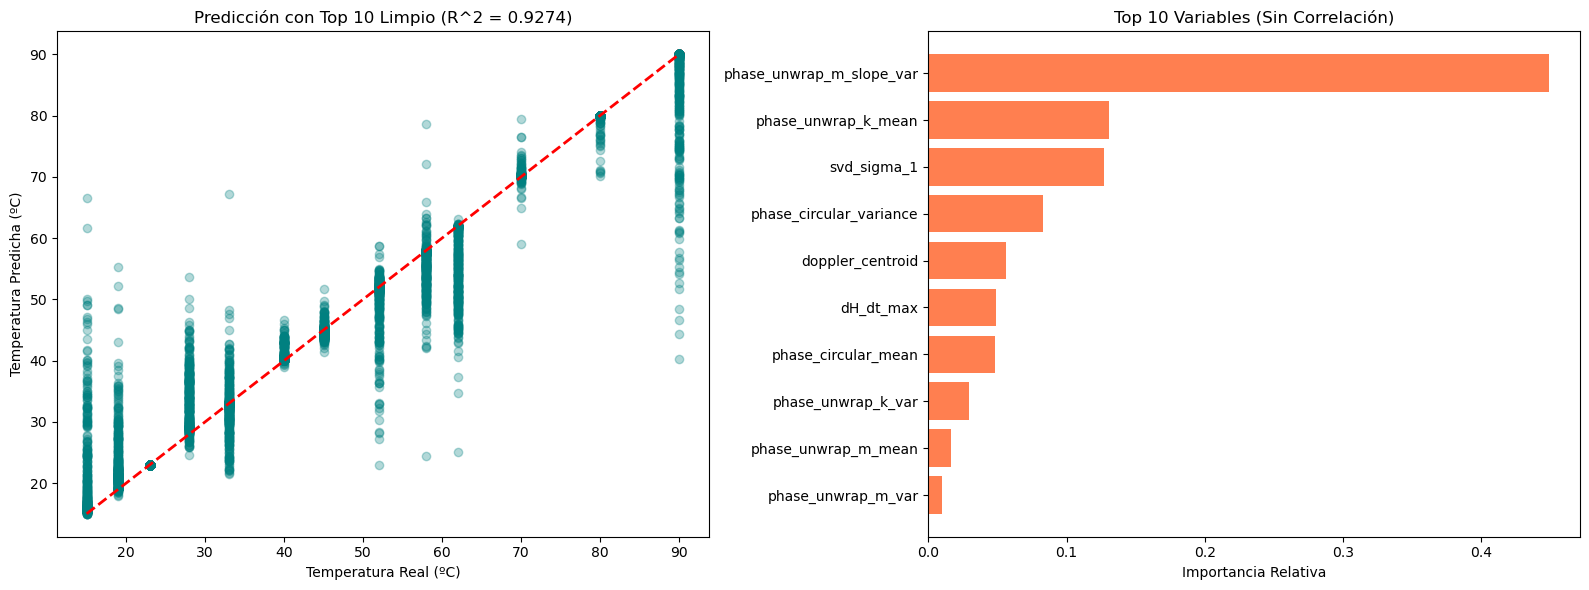

¡Modelo guardado con éxito!


['nombres_variables_top10.pkl']

In [1]:
# TOP 10 no correladas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# ==========================================
# 1. CARGAR DATOS
# ==========================================
df = pd.read_csv(r'C:\Users\Joan Daniel\Documents\UPV quinto\Commov\Codigo-ISAC\Joanda\dataset_features_temperatura.csv')

# Coger TODAS las variables dinámicas iniciales
dynamic_features = df.filter(regex='phase|doppler|dH_dt|svd').columns.tolist()
X_all = df[dynamic_features]
y = df['temperature']

# ==========================================
# FASE 1: FILTRO DE CORRELACIÓN (>0.90)
# ==========================================
print("FASE 1: Eliminando variables gemelas (Correlación > 0.90)...")
matriz_corr = X_all.corr().abs()
upper = matriz_corr.where(np.triu(np.ones(matriz_corr.shape), k=1).astype(bool))

# Encontrar y eliminar correladas
variables_correladas = [column for column in upper.columns if any(upper[column] > 0.90)]
variables_limpias = [var for var in dynamic_features if var not in variables_correladas]

print("-" * 50)
print(f"Han sobrevivido {len(variables_limpias)} variables sin alta correlación.")
print("-" * 50 + "\n")

# ==========================================
# FASE 2: RANDOM FOREST EXPLORADOR (Top 10)
# ==========================================
print("FASE 2: Analizando la importancia para extraer el Top 10...")
X_limpias = df[variables_limpias]

rf_explorador = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_explorador.fit(X_limpias, y)

# Extraer el Top 10 de las limpias
importances = rf_explorador.feature_importances_
indices_top10 = np.argsort(importances)[::-1][:10] # <-- Volvemos a cortar en 10
nuevo_top_10 = [variables_limpias[i] for i in indices_top10]

print("EL TOP 10 DEFINITIVO (Sin correlación) ES:")
for i, var in enumerate(nuevo_top_10, 1):
    print(f"{i}. {var}")
print("\n")

# ==========================================
# FASE 3: RANDOM FOREST FINAL
# ==========================================
print("FASE 3: Entrenando modelo definitivo con el Top 10 limpio...")
X_final = df[nuevo_top_10]

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

rf_final = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)

y_pred = rf_final.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("=" * 45)
print(f"R^2 Score Final (Top 10 Limpio): {r2:.4f}")
print(f"Error Absoluto Medio (MAE): {mae:.2f} ºC")
print("=" * 45)

# ==========================================
# GRÁFICAS FINALES
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gráfica de Dispersión
ax1.scatter(y_test, y_pred, alpha=0.3, color='teal')
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax1.set_xlabel('Temperatura Real (ºC)')
ax1.set_ylabel('Temperatura Predicha (ºC)')
ax1.set_title(f'Predicción con Top 10 Limpio (R^2 = {r2:.4f})')

# 2. Gráfica de Importancia (10 barras)
importances_finales = rf_final.feature_importances_
indices_finales = np.argsort(importances_finales)[::-1]

ax2.barh(range(10), importances_finales[indices_finales][::-1], align='center', color='coral')
ax2.set_yticks(range(10))
ax2.set_yticklabels([nuevo_top_10[i] for i in indices_finales][::-1])
ax2.set_title('Top 10 Variables (Sin Correlación)')
ax2.set_xlabel('Importancia Relativa')

plt.tight_layout()
plt.show()

import joblib

# rf_final es tu modelo entrenado con el Top 10
joblib.dump(rf_final, 'modelo_RF_TOP10_NoCorrelacion.pkl')
print("¡Modelo guardado con éxito!")

# Opcional pero recomendado: Guarda también el nombre de las columnas para no olvidarlas
joblib.dump(nuevo_top_10, 'nombres_variables_top10.pkl')

In [10]:
# Prueba de modelo con 18 primeras muestras OFDM

import sys
import pandas as pd
import joblib
from pathlib import Path

# =============================================================================
# 1. CONECTAR TU CARPETA CON LA DE HUGO
# =============================================================================
ruta_hugo = Path("../../Hugo").resolve()
if str(ruta_hugo) not in sys.path:
    sys.path.insert(0, str(ruta_hugo))

try:
    from channel_estimator import compute_channel_matrix_from_iq_paths
    from channel_features_complete import extract_channel_matrix_features
    print("✅ Funciones de Hugo conectadas con éxito.")
except ImportError:
    print("❌ ERROR: No se han podido importar las funciones de Hugo.")
    exit()

# =============================================================================
# 2. CARGAR TU MODELO Y EL YAML
# =============================================================================
try:
    modelo_rf = joblib.load('modelo_RF_TOP10_NoCorrelacion.pkl')
    variables_top10 = joblib.load('nombres_variables_top10.pkl')
    print("✅ Modelo de IA cargado.")
except FileNotFoundError:
    print("❌ ERROR: No encuentro el .pkl en tu carpeta.")
    exit()

# El YAML sigue estando en la carpeta 'data' general
RUTA_YAML = Path("../../data/Modulator.yaml")

# =============================================================================
# 3. RUTAS A TUS DATOS DE TEST (Directamente en tu carpeta)
# =============================================================================
# Como la carpeta está al lado de tu script, ya no hay que poner "../"
BBDD_DIR = Path("../Datos TEST Vaso carton")

# Lista con todas las muestras que tienes en tus subcarpetas
pruebas = [
    {
        "nombre": "Vaso Frío - Muestra 1",
        "tx": BBDD_DIR / "frio" / "iq_tx_1.bin",
        "rx": BBDD_DIR / "frio" / "iq_rx_1.bin"
    },
    {
        "nombre": "Vaso Frío - Muestra 2",
        "tx": BBDD_DIR / "frio" / "iq_tx_2.bin",
        "rx": BBDD_DIR / "frio" / "iq_rx_2.bin"
    },
    {
        "nombre": "Vaso Templado - Muestra 1",
        "tx": BBDD_DIR / "templado" / "iq_tx_1.bin", 
        "rx": BBDD_DIR / "templado" / "iq_rx_1.bin"
    },
    {
        "nombre": "Vaso Templado - Muestra 2",
        "tx": BBDD_DIR / "templado" / "iq_tx_2.bin", 
        "rx": BBDD_DIR / "templado" / "iq_rx_2.bin"
    },
    {
        "nombre": "Vaso Caliente - Muestra 1",
        "tx": BBDD_DIR / "caliente" / "iq_tx_1.bin",
        "rx": BBDD_DIR / "caliente" / "iq_rx_1.bin"
    },
    {
        "nombre": "Vaso Caliente - Muestra 2",
        "tx": BBDD_DIR / "caliente" / "iq_tx_2.bin",
        "rx": BBDD_DIR / "caliente" / "iq_rx_2.bin"
    }
]

# =============================================================================
# 4. LA PRUEBA FINAL
# =============================================================================
print("-" * 50)
print("INICIANDO PRUEBA DE INFERENCIA EN VIVO")
print("-" * 50)

for p in pruebas:
    if not p["tx"].exists() or not p["rx"].exists():
        print(f"⚠️ Aviso: Saltando '{p['nombre']}'. No encuentro sus archivos")
        continue
        
    try:
        # A. Estimar Canal (¡CON LOS PARÁMETROS EXACTOS DE HUGO!)
        H = compute_channel_matrix_from_iq_paths(
            tx_path=p["tx"], 
            rx_path=p["rx"], 
            yaml_path=RUTA_YAML, 
            n_symbols=None,
            start_sample_tx=0,
            start_sample_rx=0,
            storage_format_tx="auto",
            storage_format_rx="auto",
            fftshift=False,                # SUPER IMPORTANTE
            normalize_fft=False,           # SUPER IMPORTANTE
            trim_to_complete_frames=True,  # SUPER IMPORTANTE
            return_aux=False,
            output_order="mk", 
            verbose=False
        )
        
        # B. Extraer características
        todas_features = extract_channel_matrix_features(H, input_order="mk")
        
        # C. Filtrar (Tu Top 10)
        features_filtradas = {var: todas_features[var] for var in variables_top10}
        
        # D. Convertir a tabla asegurando que el orden de las columnas es perfecto
        df_pred = pd.DataFrame([features_filtradas], columns=variables_top10)
        
        # CHIVATO: Imprimimos el nombre de las variables y sus valores
        if "Muestra 1" in p["nombre"]:
            print(f"\n--- {p['nombre']} ---")
            for nombre_var, valor in list(features_filtradas.items())[:5]: # Muestra las 5 primeras
                print(f"  {nombre_var}: {valor}")
                
        # E. Predecir
        temp_detectada = modelo_rf.predict(df_pred)[0]
        
        print(f"🌡️ [{p['nombre']}] -> Predicción: {temp_detectada:.1f} ºC\n")
        
    except Exception as e:
        print(f"❌ Error procesando {p['nombre']}: {e}\n")

print("-" * 50)

✅ Funciones de Hugo conectadas con éxito.
✅ Modelo de IA cargado.
--------------------------------------------------
INICIANDO PRUEBA DE INFERENCIA EN VIVO
--------------------------------------------------

--- Vaso Frío - Muestra 1 ---
  phase_unwrap_m_slope_var: 0.008956919823955089
  phase_unwrap_k_mean: -326.6090407696133
  svd_sigma_1: 72.2835943483883
  phase_circular_variance: 0.9999024869416552
  phase_circular_mean: 2.7117980910574846
🌡️ [Vaso Frío - Muestra 1] -> Predicción: 41.7 ºC

🌡️ [Vaso Frío - Muestra 2] -> Predicción: 42.1 ºC


--- Vaso Templado - Muestra 1 ---
  phase_unwrap_m_slope_var: 0.002848832494127597
  phase_unwrap_k_mean: -328.8841589869784
  svd_sigma_1: 131.51653170504505
  phase_circular_variance: 0.9999410385676261
  phase_circular_mean: -1.5485488268990308
🌡️ [Vaso Templado - Muestra 1] -> Predicción: 42.5 ºC

🌡️ [Vaso Templado - Muestra 2] -> Predicción: 42.3 ºC


--- Vaso Caliente - Muestra 1 ---
  phase_unwrap_m_slope_var: 0.007440771651461881
  phas